# Лабораторная работа 3
## Сидимеков Дмитрий

In [ ]:
!pip install -U moabb mne scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 277.6/277.6 kB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 93.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 77.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 252.3/252.3 kB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 168.9/168.9 kB 15.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.7/127.7 kB 13.0 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1


In [ ]:
import moabb.datasets
from moabb.paradigms import P300
import torch
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
import shutil
import os

def _my_copy_tree(src, dst, symlinks=False):
    # аналог distutils.dir_util.copy_tree по-простому
    if not os.path.exists(dst):
        os.makedirs(dst)

    for item in os.listdir(src):
        s = os.path.join(src, item)
        d = os.path.join(dst, item)
        if os.path.isdir(s):
            _my_copy_tree(s, d, symlinks=symlinks)
        else:
            if not os.path.exists(os.path.dirname(d)):
                os.makedirs(os.path.dirname(d))
            if symlinks and os.path.islink(s):
                linkto = os.readlink(s)
                os.symlink(linkto, d)
            else:
                shutil.copy2(s, d)

# подпишем нашу функцию в модуль shutil
setattr(shutil, "copy_tree", _my_copy_tree)

In [ ]:

m_dataset = moabb.datasets.bi2013a(
    NonAdaptive=True,
    Adaptive=True,
    Training=True,
    Online=True,
)
m_dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
moabb_path = !pip show moabb | grep Location | cut -d " " -f 2
if moabb_path:
    moabb_path = moabb_path[0]
    preprocessing_file = f"{moabb_path}/moabb/datasets/preprocessing.py"

    with open(preprocessing_file, 'r') as f:
        content = f.read()

    if "from sklearn.utils._repr_html.estimator import _VisualBlock" in content:
        content = content.replace(
            "from sklearn.utils._repr_html.estimator import _VisualBlock",
            "# from sklearn.utils._repr_html.estimator import _VisualBlock\n_VisualBlock = None"
        )

        with open(preprocessing_file, 'w') as f:
            f.write(content)
        print("Файл успешно пропатчен!")
    else:
        print("Строка не найдена, возможно файл уже пропатчен")

import moabb.datasets as datasets

drive.mount('/content/drive', force_remount=True)
DATA_DIR = "/content/drive/MyDrive/lab3_eeg"
os.makedirs(DATA_DIR, exist_ok=True)
print("Рабочая папка для данных:", DATA_DIR)

dataset = datasets.BI2013a()
paradigm = P300()
all_subjects = range(1, 2)

Xs = []
ys = []
loaded_subjects = []

for subj in all_subjects:
    X_file = os.path.join(DATA_DIR, f"X_subject{subj}.npy")
    y_file = os.path.join(DATA_DIR, f"y_subject{subj}.npy")
    if os.path.exists(X_file) and os.path.exists(y_file):
        print(f"Субъект {subj} уже сохранён, загружаем с диска...")
        X_subj = np.load(X_file)
        y_subj = np.load(y_file)
    else:
        print(f"Скачиваем и обрабатываем субъект {subj}...")
        X_subj, y_subj, _ = paradigm.get_data(dataset, subjects=[subj])
        np.save(X_file, X_subj)
        np.save(y_file, y_subj)
        print(f"Субъект {subj} сохранён на диск.")

    Xs.append(X_subj)
    ys.append(y_subj)
    loaded_subjects.append(subj)

X = np.concatenate(Xs, axis=0)
y = np.concatenate(ys, axis=0)

Файл успешно пропатчен!
Mounted at /content/drive
Рабочая папка для данных: /content/drive/MyDrive/lab3_eeg
Субъект 1 уже сохранён, загружаем с диска...


In [ ]:
m_dataset = moabb.datasets.bi2013a(
    NonAdaptive=True,
    Adaptive=True,
    Training=True,
    Online=True,
)

paradigm = P300(
    resample = 128,
    tmin=0.2,
    tmax=0.8
)

subjects = m_dataset.subject_list[1]

X, y, meta = paradigm.get_data(
    dataset=m_dataset,
    subjects=subjects
)

In [ ]:
m_dataset[:10]

NameError: name 'm_dataset' is not defined

In [ ]:
print("X shape:", X.shape)
print("Количество эпох:", X.shape[0])
print("Количество каналов:", X.shape[1])
print("Количество временных отсчётов:", X.shape[2])
print("Классы:", np.unique(y, return_counts=True))
print("Доля Target:", np.mean(y == "Target"))
print("Доля NonTarget:", np.mean(y == "NonTarget"))

In [ ]:
print(X.shape)        # (N_trials, N_channels, N_samples)
print(y.shape)        # (N_trials,)
# print(meta.head())
print(set(y))         # посмотреть уникальные метки

(3840, 16, 513)
(3840,)
{np.str_('Target'), np.str_('NonTarget')}


### Предобработка данных

In [ ]:
y_num = np.where(y == "Target", 1, -1)
y_num = np.where(y == "Target", 1, -1)
n, ch, ts = X.shape
X_flat = X.reshape(n, ch * ts)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X_flat, y_num, test_size=0.2, random_state=42, stratify=y_num
)

In [ ]:
(y_num>0).sum() / y_num.shape[0]

np.float64(0.16666666666666666)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

In [ ]:
def accuracy_score(y_true, y_pred):
    return (y_true == y_pred).float().mean().item()

def precision_recall_f1(y_true, y_pred):
    tp = ((y_true == 1) & (y_pred == 1)).sum().item()
    fp = ((y_true == 0) & (y_pred == 1)).sum().item()
    fn = ((y_true == 1) & (y_pred == 0)).sum().item()

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
    return precision, recall, f1

In [ ]:
class SVMClassifier:
    def __init__(self, lr=1e-3, C=0.1, epochs=100, batch_size=64, device=None, print_every=25) -> None:
        self.C = C
        self.lr = lr
        self.epochs = epochs
        self.batch_size = batch_size
        self.print_every = print_every
        self.w = None
        self.b = None
        self.hist_w = None
        self.hist = {}
        self.device = device or torch.device("cpu")

    def _init_params(self, n_features):
        self.hist_w = []
        self.hist = {
            "tr_loss": [],
            "tr_acc": [],
            "tr_f1": [],
            "val_loss": [],
            "val_acc": [],
            "val_f1": [],
        }
        self.w = torch.zeros(n_features, device=self.device)
        self.b = torch.zeros(1, device=self.device)

    def fit(
        self,
        X_train: torch.Tensor,
        y_train: torch.Tensor,
        X_val: torch.Tensor,
        y_val: torch.Tensor,
    ):
        _, n_features = X_train.shape
        self._init_params(n_features)

        X_train = X_train.to(self.device).float()
        X_val = X_val.to(self.device).float()
        y_train = y_train.to(self.device).float()
        y_val = y_val.to(self.device).float()

        N_train, _ = X_train.shape
        N_val, _ = X_val.shape

        for epoch in range(self.epochs):
            idx_rnd_tr = torch.randperm(N_train, device=self.device)
            tr_loss, tr_acc, tr_f1 = 0.0, 0.0, 0.0
            val_loss, val_acc, val_f1 = 0.0, 0.0, 0.0

            # train
            for start in range(0, N_train, self.batch_size):
                end = min(N_train, start + self.batch_size)
                idx = idx_rnd_tr[start:end]

                X_batch_tr = X_train[idx]
                y_batch_tr = y_train[idx]

                acc, f1, loss = self._step(X_batch_tr, y_batch_tr)
                tr_loss += loss.item()
                tr_acc += acc
                tr_f1 += f1

            idx_rnd_val = torch.randperm(N_val, device=self.device)

            # val
            for start in range(0, N_val, self.batch_size):
                end = min(N_val, start + self.batch_size)
                idx = idx_rnd_val[start:end]

                X_batch_val = X_val[idx]
                y_batch_val = y_val[idx]

                acc, f1, loss = self._val_metrics(X_batch_val, y_batch_val)
                val_loss += loss.item()
                val_acc += acc
                val_f1 += f1

            n_tr_batches = (N_train + self.batch_size - 1) // self.batch_size
            n_val_batches = (N_val + self.batch_size - 1) // self.batch_size

            self.hist["tr_loss"].append(tr_loss / n_tr_batches)
            self.hist["tr_acc"].append(tr_acc / n_tr_batches)
            self.hist["tr_f1"].append(tr_f1 / n_tr_batches)
            self.hist["val_loss"].append(val_loss / n_val_batches)
            self.hist["val_acc"].append(val_acc / n_val_batches)
            self.hist["val_f1"].append(val_f1 / n_val_batches)

            if (epoch + 1) % self.print_every == 0:
                print(
                    f"EPOCH {epoch + 1}:\n"
                    f"Train - Loss: {tr_loss/n_tr_batches:.3f}, Acc: {tr_acc/n_tr_batches:.3f}, F1: {tr_f1/n_tr_batches:.3f}\n"
                    f"Val   - Loss: {val_loss/n_val_batches:.3f}, Acc: {val_acc/n_val_batches:.3f}, F1: {val_f1/n_val_batches:.3f}\n"
                )

    def _step(self, X_batch: torch.Tensor, y_batch: torch.Tensor):
        scores = X_batch @ self.w + self.b
        preds = torch.sign(scores)
        margin = y_batch * (scores)
        xi = 1.0 - margin
        mask = (xi > 0).float()

        pos_mask = (y_batch > 0).float()
        neg_mask = (y_batch < 0).float()

        n_pos = pos_mask.sum().clamp(min=1.0)
        n_neg = neg_mask.sum().clamp(min=1.0)

        # вес положительного класса больше (его около 16% только)
        w_pos = n_neg / (n_pos + n_neg)
        w_neg = n_pos / (n_pos + n_neg)

        sample_weight = w_pos * pos_mask + w_neg * neg_mask

        hinge = torch.clamp(xi, min=0.0) * sample_weight

        L = 0.5 * torch.sum(self.w * self.w) + self.C * hinge.mean()

        N = X_batch.shape[0]

        y_sv = y_batch * mask * sample_weight

        dLdw = self.w - self.C * (X_batch.T @ y_sv) / N
        dLdb = -self.C * y_sv.mean()

        self.w -= self.lr * dLdw
        self.b -= self.lr * dLdb

        acc, f1 = self._compute_metrics(y_batch, preds)
        return acc, f1, L

    def _val_metrics(self, X_batch, y_batch):
        scores = X_batch @ self.w + self.b
        preds = torch.sign(scores)
        margin = y_batch * (scores)
        xi = 1.0 - margin

        hinge = torch.clamp(xi, min=0.0)

        L = 0.5 * torch.sum(self.w * self.w) + self.C * hinge.mean()

        # pos_rate = (preds > 0).float().mean().item()
        # print("Val positive prediction rate:", pos_rate)


        acc, f1 = self._compute_metrics(y_batch, preds)
        return acc, f1, L

    def _compute_metrics(self, y_batch, preds):
        # -1,1 в 0,1
        y_true_bin = (y_batch > 0).int()
        y_pred_bin = (preds > 0).int()

        acc = accuracy_score(y_true_bin, y_pred_bin)
        _, _, f1 = precision_recall_f1(y_true_bin, y_pred_bin)

        return acc, f1

    def predict(self, X):
        X = X.to(device=self.device)
        y_pred = X @ self.w + self.b
        return torch.where(y_pred >= 0, 1.0, -1.0).to(self.device)

    def plot_metrics(self, figsize=(15, 10)):
        epochs = range(1, len(self.hist['tr_loss']) + 1)

        fig, axes = plt.subplots(2, 3, figsize=figsize)
        fig.suptitle('SVM Classifier metrics', fontsize=16, fontweight='bold')

        # Loss
        axes[0, 0].plot(epochs, self.hist['tr_loss'], 'b-', label='Train Loss', linewidth=2)
        axes[0, 0].plot(epochs, self.hist['val_loss'], 'r-', label='Val Loss', linewidth=2)
        axes[0, 0].set_title('Loss')
        axes[0, 0].set_xlabel('Epoch')
        axes[0, 0].set_ylabel('Loss')
        axes[0, 0].legend()
        axes[0, 0].grid(True, alpha=0.3)

        # Accuracy
        axes[0, 1].plot(epochs, self.hist['tr_acc'], 'b-', label='Train Accuracy', linewidth=2)
        axes[0, 1].plot(epochs, self.hist['val_acc'], 'r-', label='Val Accuracy', linewidth=2)
        axes[0, 1].set_title('Accuracy')
        axes[0, 1].set_xlabel('Epoch')
        axes[0, 1].set_ylabel('Accuracy')
        axes[0, 1].set_ylim(0, 1)
        axes[0, 1].legend()
        axes[0, 1].grid(True, alpha=0.3)

        # F1
        axes[0, 2].plot(epochs, self.hist['tr_f1'], 'b-', label='Train F1-Score', linewidth=2)
        axes[0, 2].plot(epochs, self.hist['val_f1'], 'r-', label='Val F1-Score', linewidth=2)
        axes[0, 2].set_title('F1-Score')
        axes[0, 2].set_xlabel('Epoch')
        axes[0, 2].set_ylabel('F1-Score')
        axes[0, 2].set_ylim(0, 1)
        axes[0, 2].legend()
        axes[0, 2].grid(True, alpha=0.3)

        # Error Rate (1 - Accuracy)
        tr_error = [1 - acc for acc in self.hist['tr_acc']]
        val_error = [1 - acc for acc in self.hist['val_acc']]

        axes[1, 0].plot(epochs, tr_error, 'b-', label='Train Error', linewidth=2)
        axes[1, 0].plot(epochs, val_error, 'r-', label='Val Error', linewidth=2)
        axes[1, 0].set_title('Error Rate (1 - Accuracy)')
        axes[1, 0].set_xlabel('Epoch')
        axes[1, 0].set_ylabel('Error Rate')
        axes[1, 0].set_ylim(0, 1)
        axes[1, 0].legend()
        axes[1, 0].grid(True, alpha=0.3)

        # Loss vs Accuracy (двойная ось Y)
        ax2 = axes[1, 1].twinx()
        line1 = axes[1, 1].plot(epochs, self.hist['tr_loss'], 'b-', label='Train Loss', linewidth=2)
        line2 = ax2.plot(epochs, self.hist['tr_acc'], 'b--', label='Train Accuracy', linewidth=2)
        line3 = axes[1, 1].plot(epochs, self.hist['val_loss'], 'r-', label='Val Loss', linewidth=2)
        line4 = ax2.plot(epochs, self.hist['val_acc'], 'r--', label='Val Accuracy', linewidth=2)

        axes[1, 1].set_title('Loss vs Accuracy')
        axes[1, 1].set_xlabel('Epoch')
        axes[1, 1].set_ylabel('Loss')
        ax2.set_ylabel('Accuracy')
        ax2.set_ylim(0, 1)

        # Объединяем легенды
        lines = line1 + line2 + line3 + line4
        labels = [l.get_label() for l in lines]
        axes[1, 1].legend(lines, labels, loc='center right')
        axes[1, 1].grid(True, alpha=0.3)

        # Пустой subplot для симметрии или можно добавить другую метрику
        axes[1, 2].axis('off')
        # Или можно добавить текстовую информацию о лучших метриках
        best_val_acc = max(self.hist['val_acc'])
        best_val_f1 = max(self.hist['val_f1'])
        best_epoch = np.argmax(self.hist['val_acc']) + 1

        axes[1, 2].text(0.1, 0.7, f'Best Validation:\n\nAccuracy: {best_val_acc:.3f}\nF1-Score: {best_val_f1:.3f}\nEpoch: {best_epoch}',
                       fontsize=12, bbox=dict(boxstyle="round,pad=0.3", facecolor="lightgray"))

        plt.tight_layout()
        plt.show()


    def get_best_metrics(self):
        best_val_acc = max(self.hist['val_acc'])
        best_val_f1 = max(self.hist['val_f1'])
        best_epoch = np.argmax(self.hist['val_acc']) + 1

        return {
            'best_accuracy': best_val_acc,
            'best_f1_score': best_val_f1,
            'best_epoch': best_epoch
        }

EPOCH 50:
Train - Loss: 0.506, Acc: 0.930, F1: 0.825
Val   - Loss: 2.455, Acc: 0.922, F1: 0.789

EPOCH 100:
Train - Loss: 0.479, Acc: 0.947, F1: 0.857
Val   - Loss: 2.540, Acc: 0.911, F1: 0.756

EPOCH 150:
Train - Loss: 0.471, Acc: 0.947, F1: 0.864
Val   - Loss: 1.970, Acc: 0.934, F1: 0.812

EPOCH 200:
Train - Loss: 0.444, Acc: 0.954, F1: 0.877
Val   - Loss: 1.889, Acc: 0.938, F1: 0.827

EPOCH 250:
Train - Loss: 0.483, Acc: 0.957, F1: 0.881
Val   - Loss: 1.990, Acc: 0.934, F1: 0.817

EPOCH 300:
Train - Loss: 0.421, Acc: 0.965, F1: 0.904
Val   - Loss: 2.036, Acc: 0.926, F1: 0.798

EPOCH 350:
Train - Loss: 0.422, Acc: 0.963, F1: 0.897
Val   - Loss: 1.833, Acc: 0.941, F1: 0.834

EPOCH 400:
Train - Loss: 0.446, Acc: 0.962, F1: 0.891
Val   - Loss: 1.786, Acc: 0.941, F1: 0.833

EPOCH 450:
Train - Loss: 0.457, Acc: 0.958, F1: 0.883
Val   - Loss: 2.174, Acc: 0.921, F1: 0.772

EPOCH 500:
Train - Loss: 0.413, Acc: 0.965, F1: 0.900
Val   - Loss: 1.941, Acc: 0.924, F1: 0.788

EPOCH 550:
Train - Lo

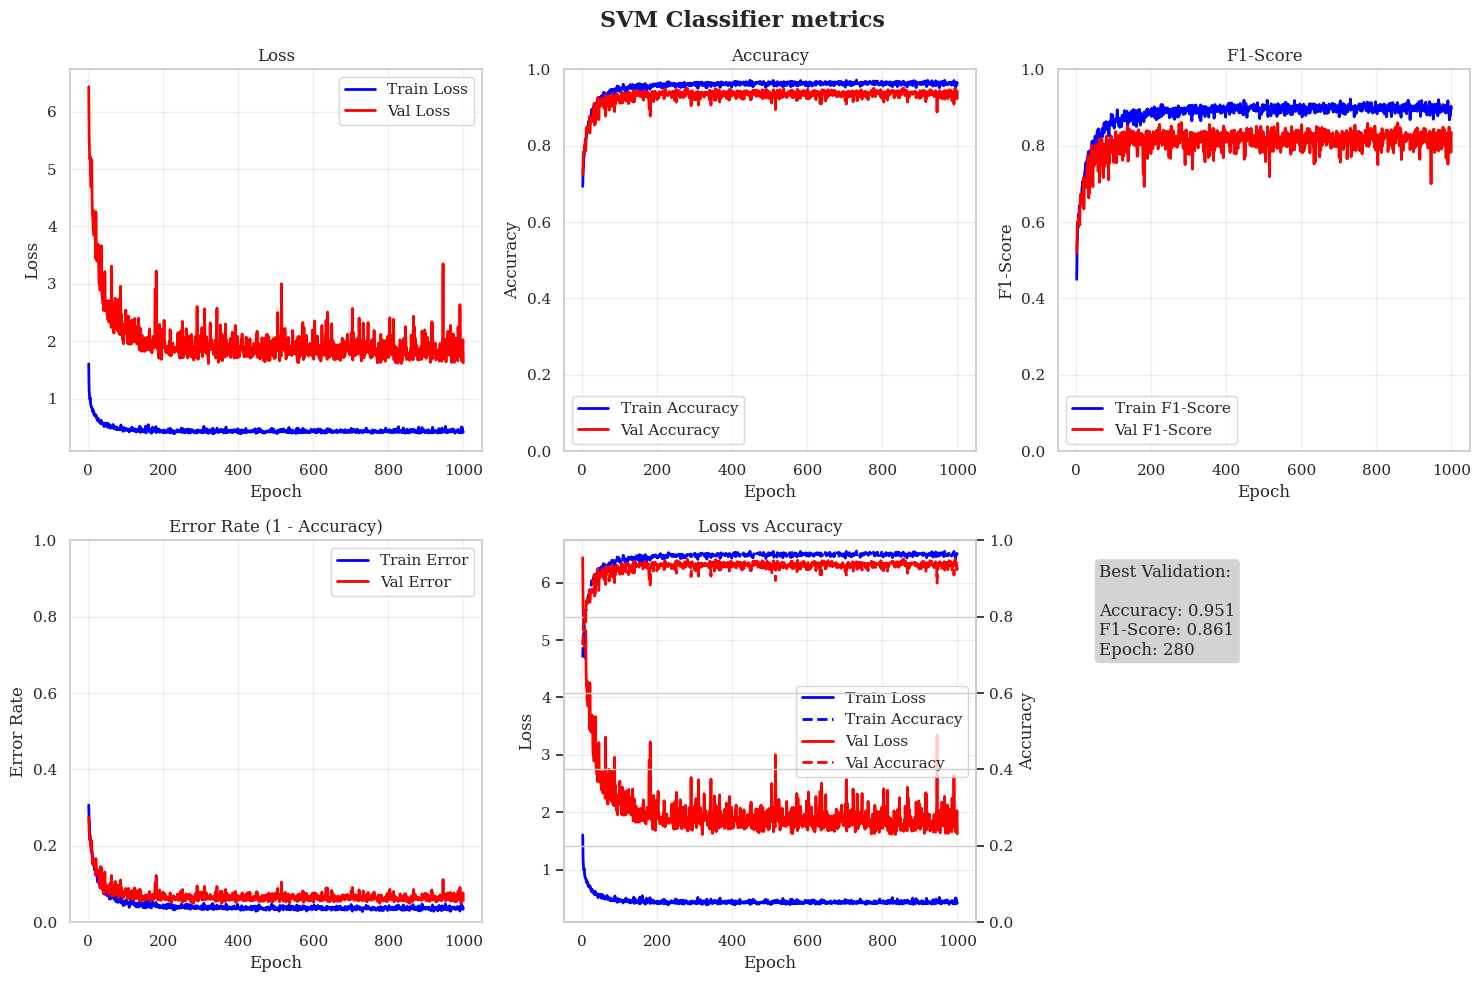

{'best_accuracy': 0.9505208333333334, 'best_f1_score': 0.860834560628375, 'best_epoch': np.int64(280)}


In [ ]:
X_tr_t = torch.from_numpy(X_train)
y_tr_t = torch.from_numpy(y_train)

X_val_t = torch.from_numpy(X_val)
y_val_t = torch.from_numpy(y_val)

svm = SVMClassifier(C=10, lr=3e-3, epochs=1000, batch_size=256, device="cuda", print_every=50)
svm.fit(X_tr_t, y_tr_t, X_val_t, y_val_t)

svm.plot_metrics()
print(svm.get_best_metrics())

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

y_val_pred = svm.predict(X_val_t).detach().cpu().numpy()

y_val_true_bin = (y_val == 1).astype(int)
y_val_pred_bin = (y_val_pred == 1).astype(int)

print("Accuracy:", accuracy_score(y_val_true_bin, y_val_pred_bin))
print("Precision:", precision_score(y_val_true_bin, y_val_pred_bin))
print("Recall:", recall_score(y_val_true_bin, y_val_pred_bin))
print("F1:", f1_score(y_val_true_bin, y_val_pred_bin))

print(classification_report(y_val_true_bin, y_val_pred_bin, target_names=["NonTarget", "Target"]))

**ROC кривая**

In [ ]:
def roc_curve():
    